# AI 221 Assignment 02

This notebook demonstrates Exploratory Data Analysis (EDA) on the Wine Quality Dataset that can be found on https://archive.ics.uci.edu/dataset/186/wine+quality.

Notebook Author: Adrian Josele G. Quional
<br>
Submitted to: Dr. Jon Dewitt E. Dalisay
<br>
Semester/Year: 2nd Semester/2024-2025

In [1]:
# importing UCI repo
# Note: Before importing make sure to install first the UCI ML repo (if the dataset is not manually downloaded) using the command pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

## Performing preliminary checks

In [2]:
# fetching the wine quality dataset 
wine_quality = fetch_ucirepo(id=186) # alternatively: fetch_ucirepo(name='Wine Quality')

# checking metadata
print("Metadata:")
print(wine_quality.metadata) 
print()

# checking variable information
print("Variable information:")
print(wine_quality.variables) 

Metadata:
{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine p

In [3]:
# saving the original (all features and target) data (as a pandas DataFrame) 
wine_quality_df = wine_quality.data.original
display(wine_quality_df)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


There are 6497 instances, 11 features, and 2 possible targets (quality and color).

In [4]:
# checking info of the DataFrame
wine_quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


All are numerical columns except color (string/object). 

In [5]:
# checking preliminary statistics on all features (thus, except the "quality" and "color" columns)
wine_quality_df.drop(["quality", "color"], axis=1).describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


In [6]:
# checking missing values
print(f"Missing values in the DataFrame: \n{wine_quality_df.isnull().sum()}\n")

Missing values in the DataFrame: 
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
dtype: int64



It is then evident that there are no missing values (as also explicitly mentioned in the dataset website).

## Performing visualization and further EDA

In [7]:
# imports
import numpy as np # for calculations
import matplotlib.pyplot as plt # for plotting
import seaborn as sns # for plotting

### Checking the distribution of possible targets: wine quality and color

In [8]:
# checking number of unique values for quality
print("Number of unique instances of wine quality:")
wine_quality_df["quality"].value_counts()

Number of unique instances of wine quality:


quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

It can be seen that there is no wine quality 0-2 and 10.

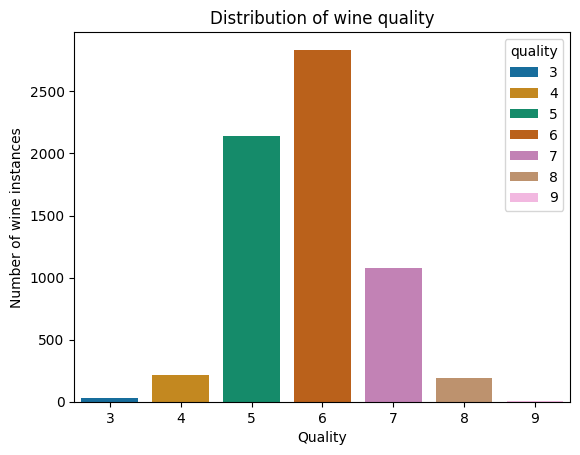

In [9]:
# checking the distribution of wine quality
sns.countplot(data=wine_quality_df, x="quality", hue="quality", palette="colorblind")
plt.xlabel("Quality")
plt.ylabel("Number of wine instances")
plt.title("Distribution of wine quality")
plt.show()

As can be seen, the dataset is not balanced in terms of wine quality (there is obviously more wine with quality 6 than other value).

In [10]:
# checking number of unique values for wine color
print("Number of unique instances of wine color:")
wine_quality_df["color"].value_counts()

Number of unique instances of wine color:


color
white    4898
red      1599
Name: count, dtype: int64

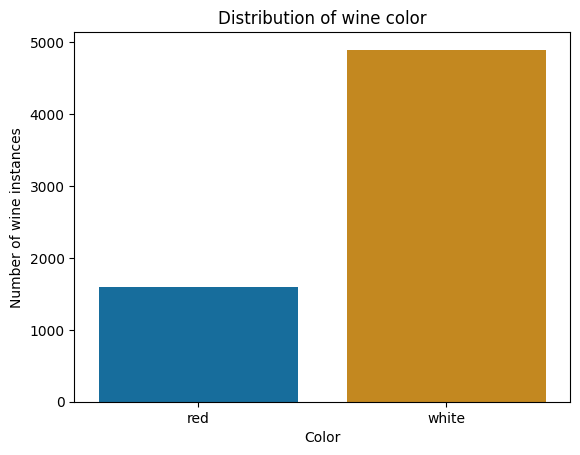

In [11]:
# checking the distribution of quality
sns.countplot(data=wine_quality_df, x="color", hue="color", palette="colorblind")
plt.xlabel("Color")
plt.ylabel("Number of wine instances")
plt.title("Distribution of wine color")
plt.show()

Obviously, in terms of wine color, the dataset is imbalanced again: there is definitely much more white wine than red wine.

To adress data imbalance, different strategies can be implemented, depending on the objective. One such strategy is using Synthetic Minority Oversampling Technique or SMOTE. More information on https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/.

### Checking the relationship of the features to one another

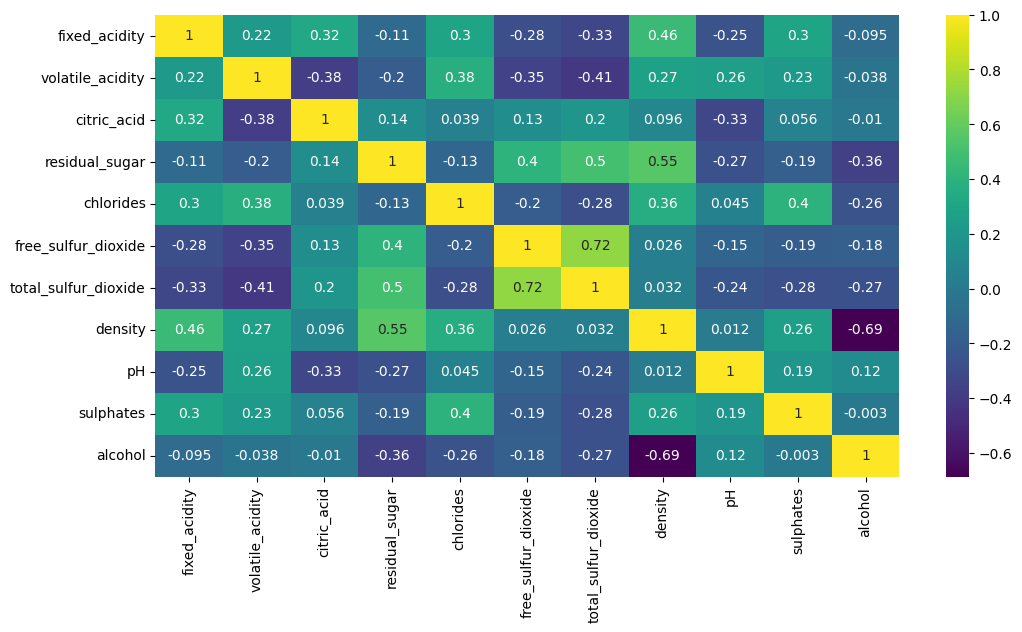

In [12]:
# creating a correlation map since a pairplot is not feasible due to the number features
plt.figure(figsize=(12, 6))
features_corr = wine_quality_df.drop(columns=["quality", "color"]).corr()
sns.heatmap(features_corr, annot=True, cmap="viridis")
plt.show()

In [13]:
# getting only the upper triangle of correlation matrix (excluding diagonal) to eliminate redundant values and self-correlations
upper_corrs = features_corr.where(np.triu(np.ones(features_corr.shape), k=1).astype(bool))

# unstacking and sorting the correlation values
sorted_corrs = upper_corrs.unstack().sort_values(ascending=False)

# remove NaNs resulting from masking the lower triangle
sorted_corrs = sorted_corrs.dropna()

# getting the Top 5 positive correlations
top_5_positive_corrs = sorted_corrs[sorted_corrs > 0].head()

# getting the Top 5 negative correlations
top_5_negative_corrs = sorted_corrs[sorted_corrs < 0].sort_values(ascending=True).head()

print("Top 5 Positive Correlations:")
print(top_5_positive_corrs)
print()

print("Top 5 Negative Correlations:")
print(top_5_negative_corrs)

Top 5 Positive Correlations:
total_sulfur_dioxide  free_sulfur_dioxide    0.720934
density               residual_sugar         0.552517
total_sulfur_dioxide  residual_sugar         0.495482
density               fixed_acidity          0.458910
free_sulfur_dioxide   residual_sugar         0.402871
dtype: float64

Top 5 Negative Correlations:
alcohol               density            -0.686745
total_sulfur_dioxide  volatile_acidity   -0.414476
citric_acid           volatile_acidity   -0.377981
alcohol               residual_sugar     -0.359415
free_sulfur_dioxide   volatile_acidity   -0.352557
dtype: float64


These correlations can later be considered in the predictive model. Do these correlated features have a combined effect on predicting, say, the wine quality or color?

### Checking the relationship of the features to the targets (wine quality and color)

In [14]:
# getting feature column names to easily loop through in the visualization below
feature_column_names = wine_quality_df.columns[:-2].values
print(feature_column_names)

['fixed_acidity' 'volatile_acidity' 'citric_acid' 'residual_sugar'
 'chlorides' 'free_sulfur_dioxide' 'total_sulfur_dioxide' 'density' 'pH'
 'sulphates' 'alcohol']


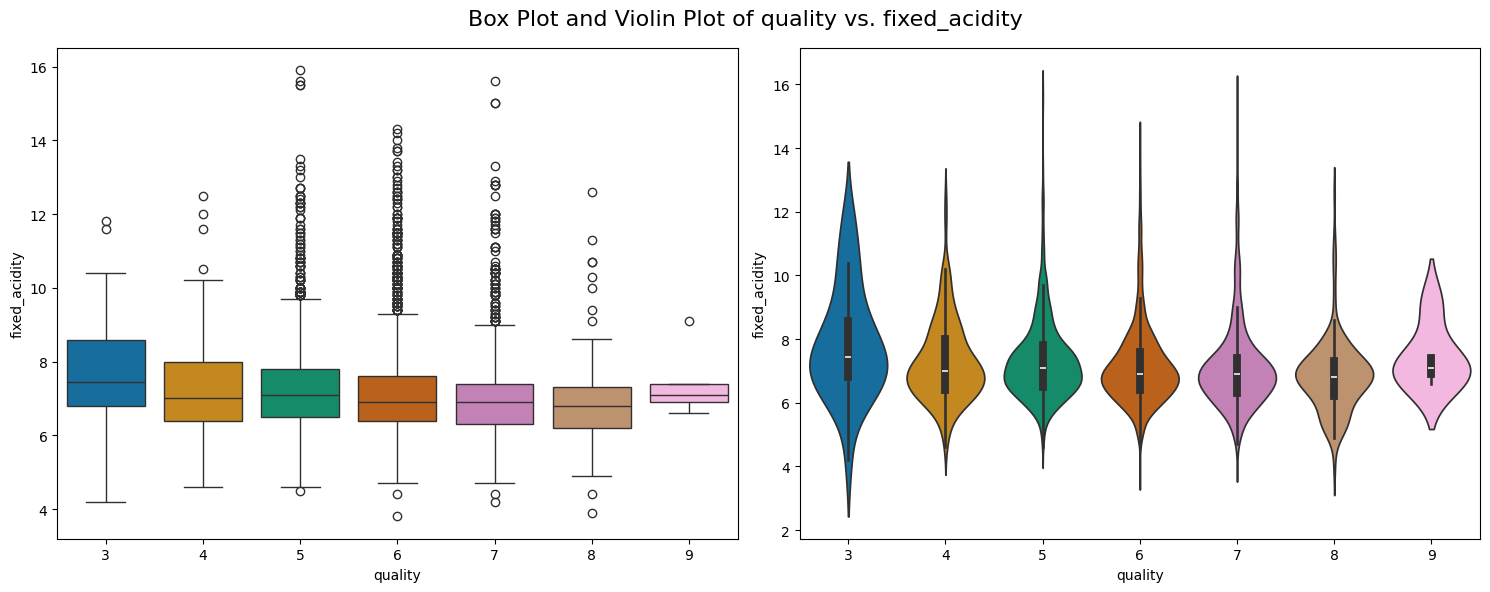

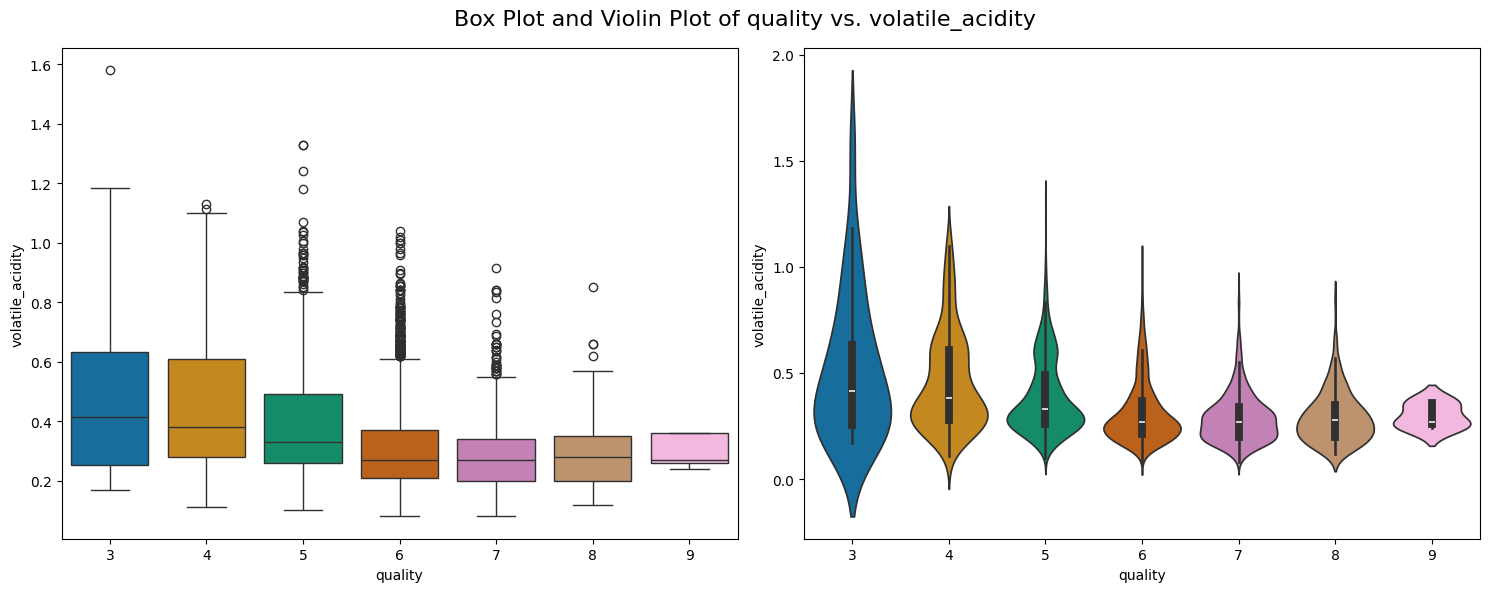

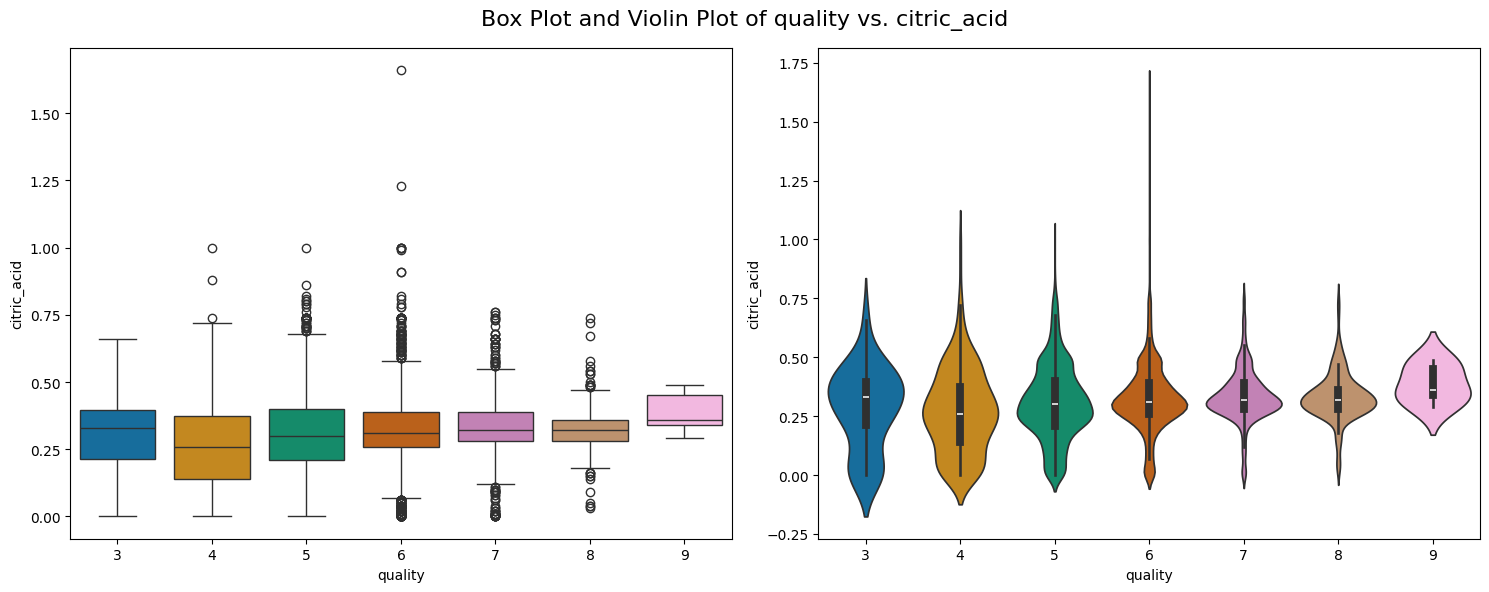

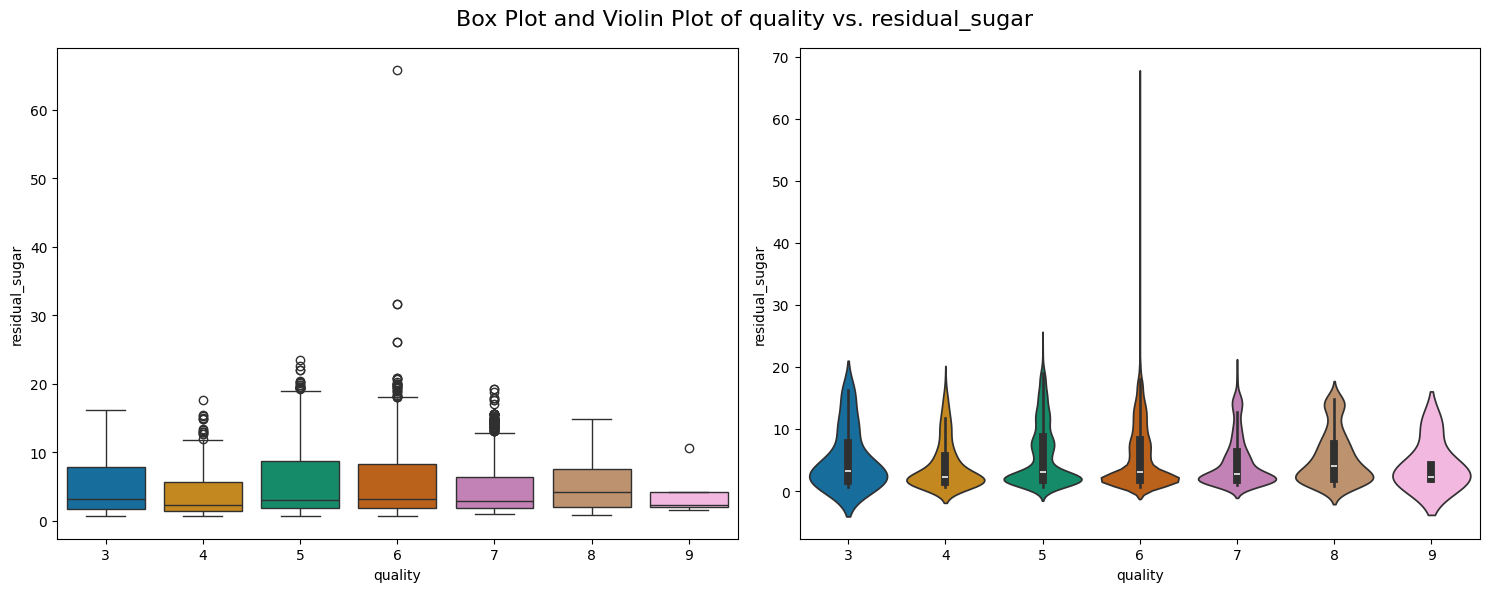

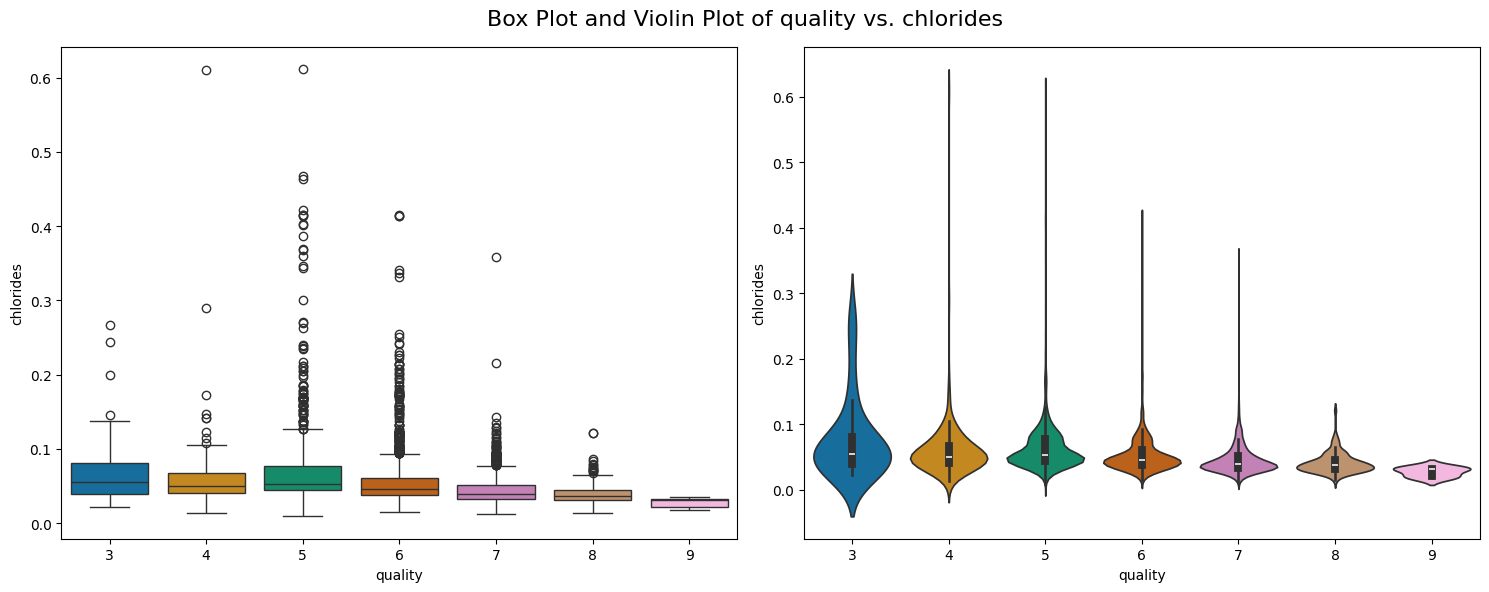

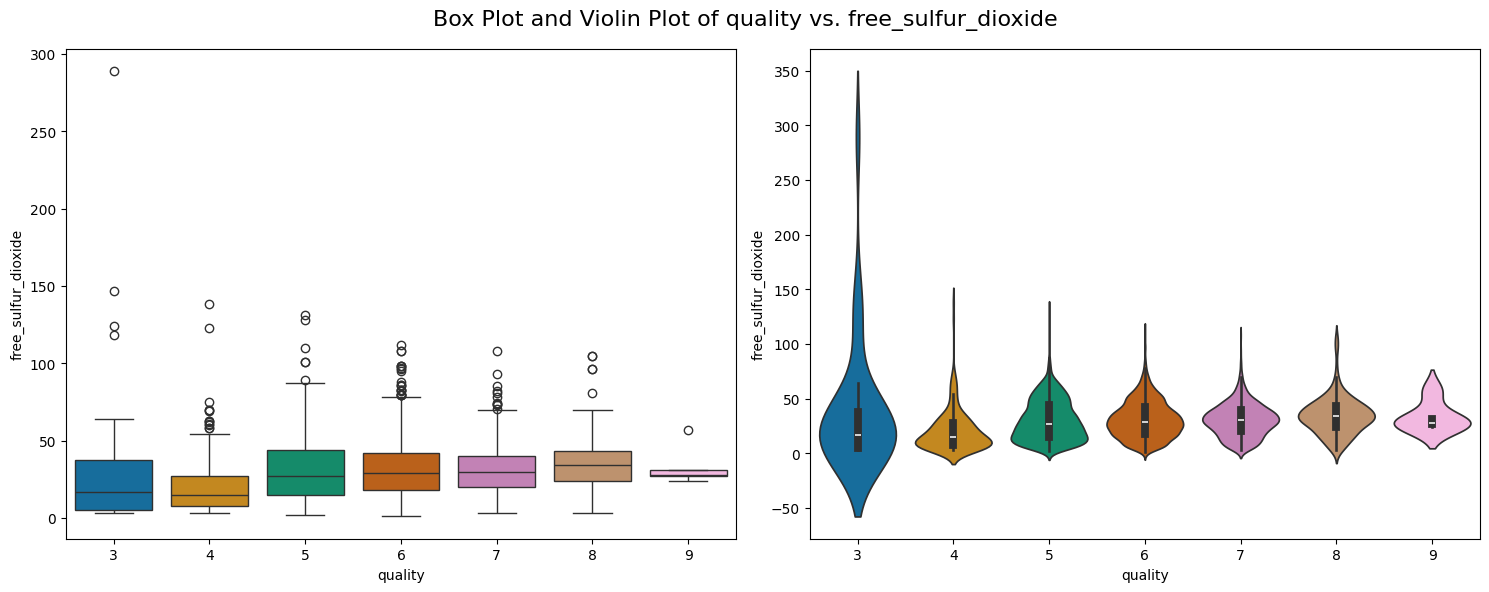

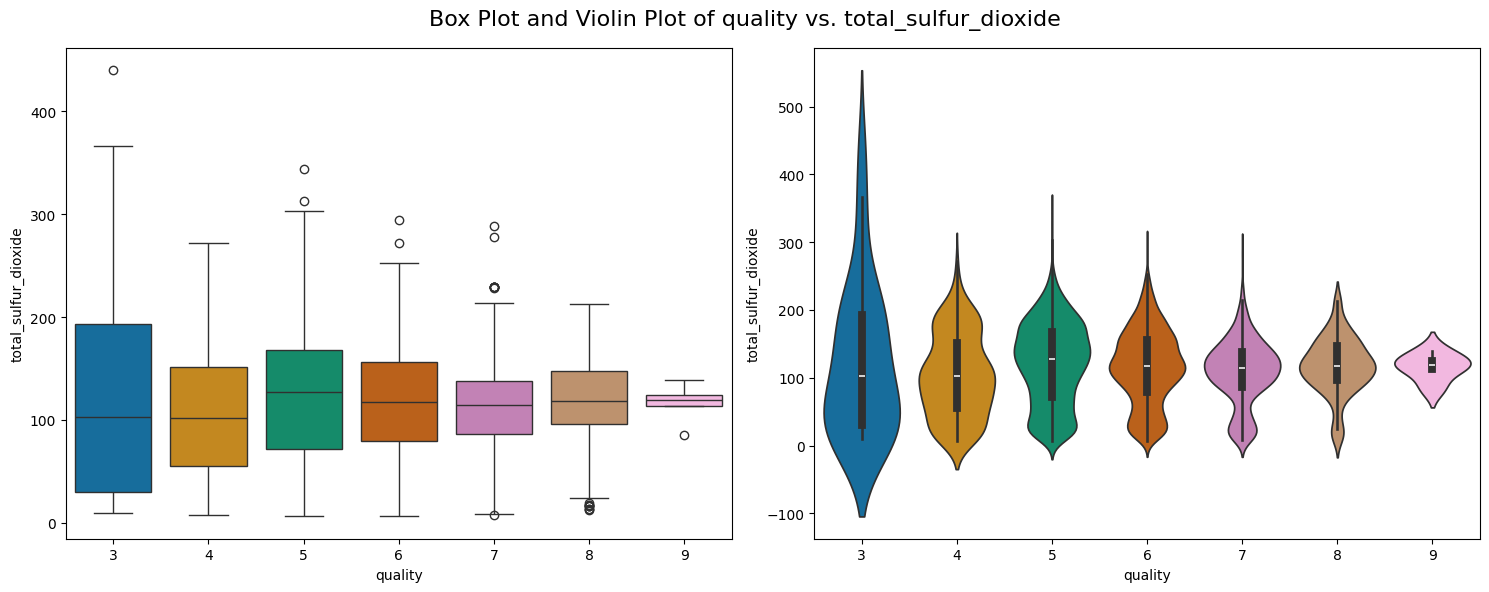

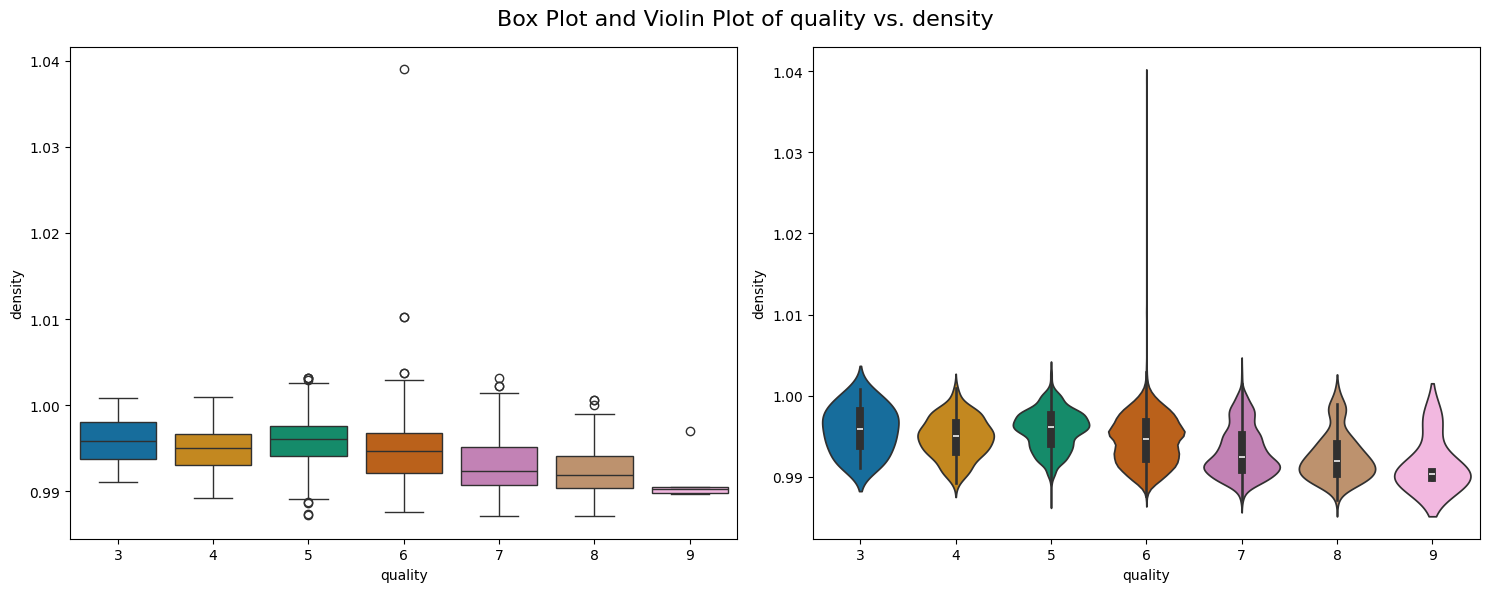

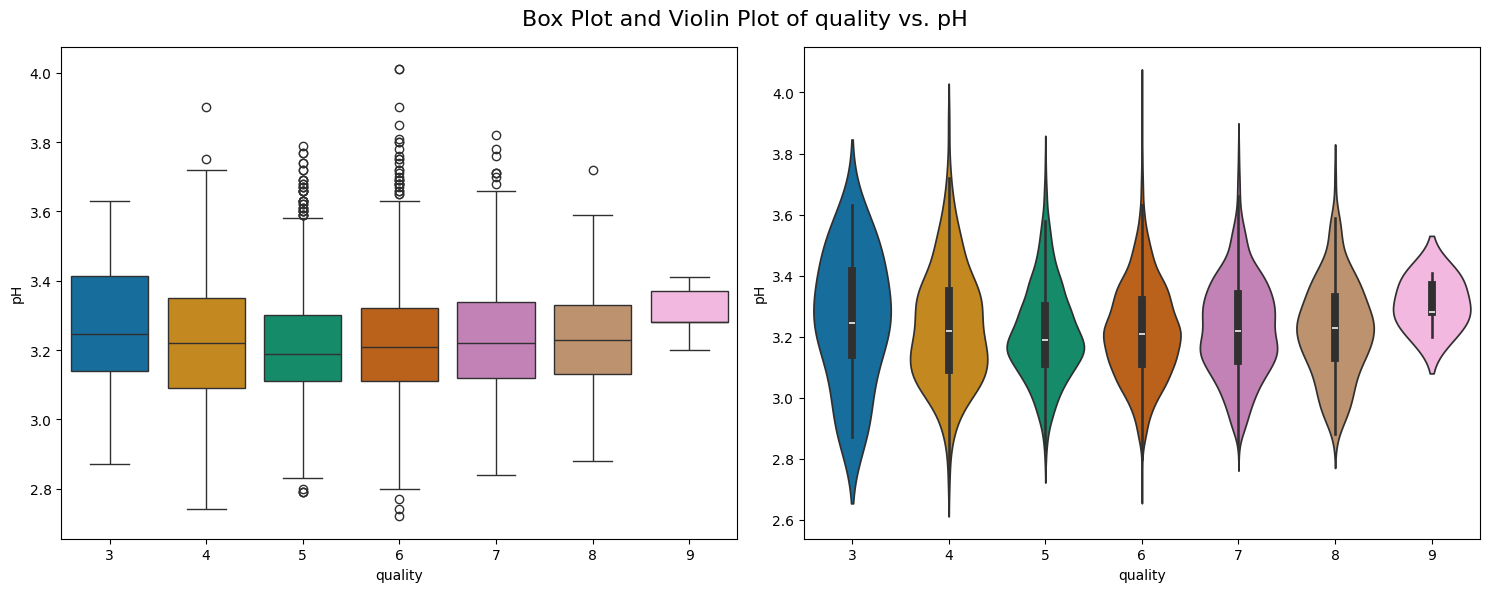

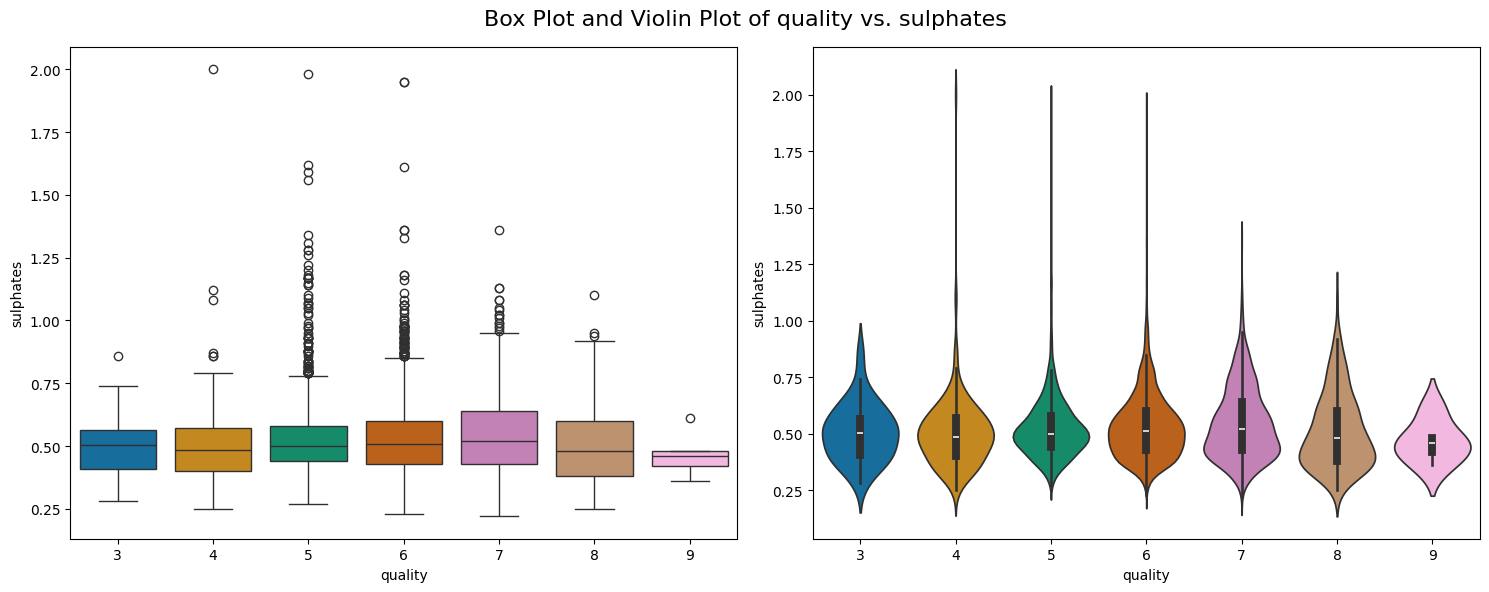

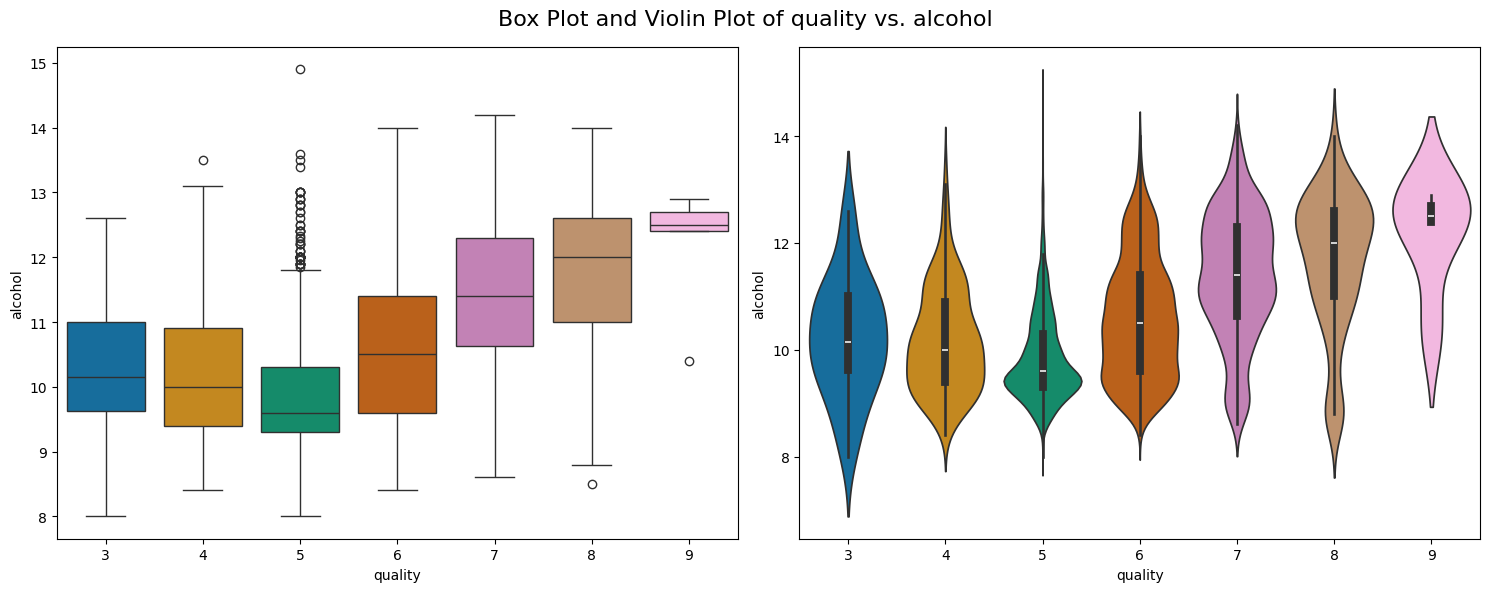

In [15]:
# visualizing distribution of features with respect to wine quality
for feature in feature_column_names:
    # setting up the subplots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))  # 1 row, 2 columns

    # creating the box plot
    sns.boxplot(data=wine_quality_df, x="quality", y=f"{feature}", hue="quality", palette="colorblind", legend=False, ax=axes[0])
    axes[0].set_xlabel('quality')
    axes[0].set_ylabel(f'{feature}')

    # creating the violin plot
    sns.violinplot(data=wine_quality_df, x="quality", y=f"{feature}", hue="quality", palette="colorblind", legend=False, ax=axes[1])
    axes[1].set_xlabel('quality')
    axes[1].set_ylabel(f'{feature}')

    fig.suptitle(f'Box Plot and Violin Plot of quality vs. {feature}', fontsize=16)
    plt.tight_layout()
    plt.show()

    print() # for spacing between plots

Almost all features don't have much variation when looked across wine quality, but there is a feature that stands out in terms of variation across wine quality: `alcohol`. It is suggested to conduct hypothesis testing to see if this variation is significant.

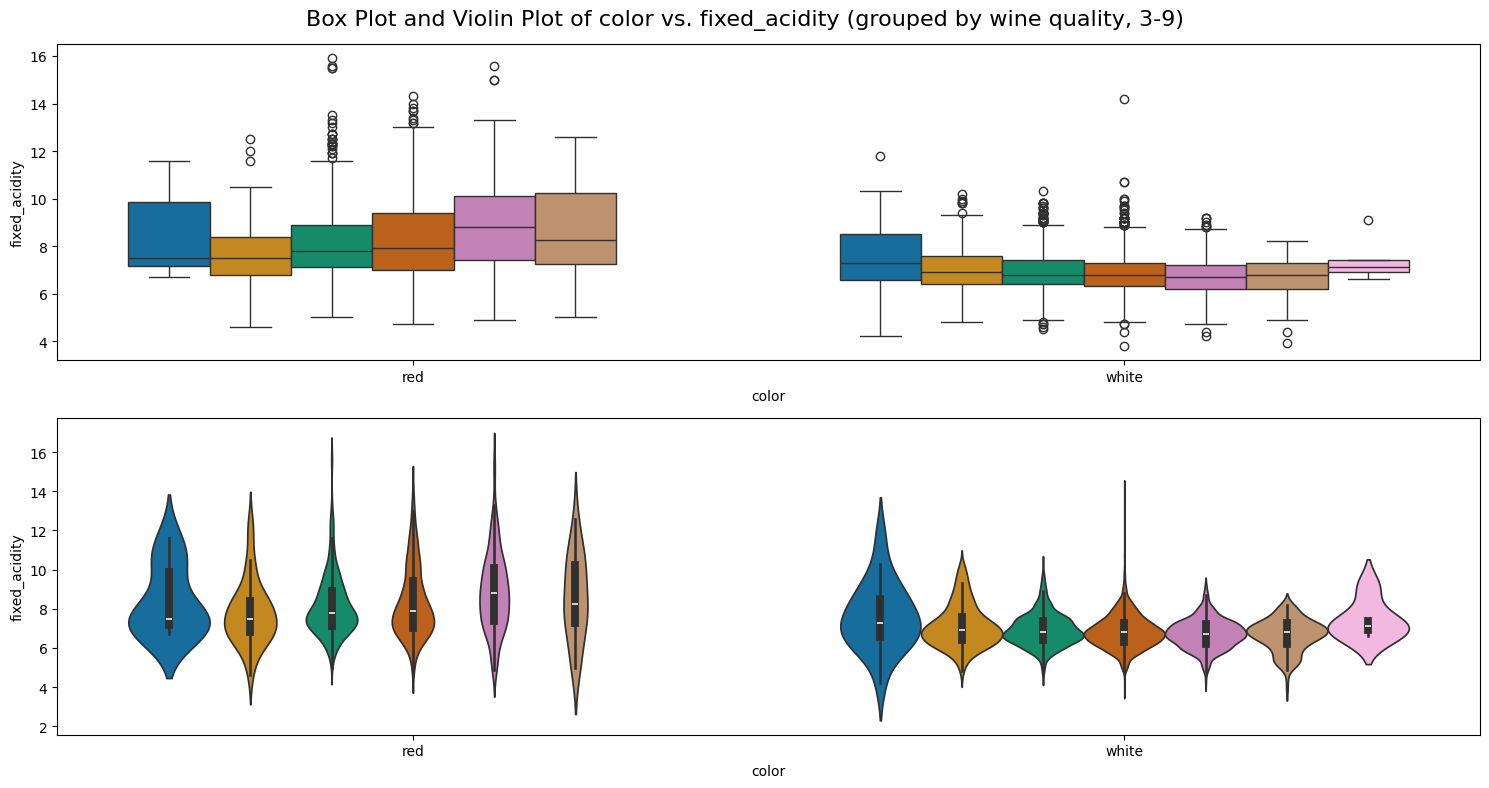

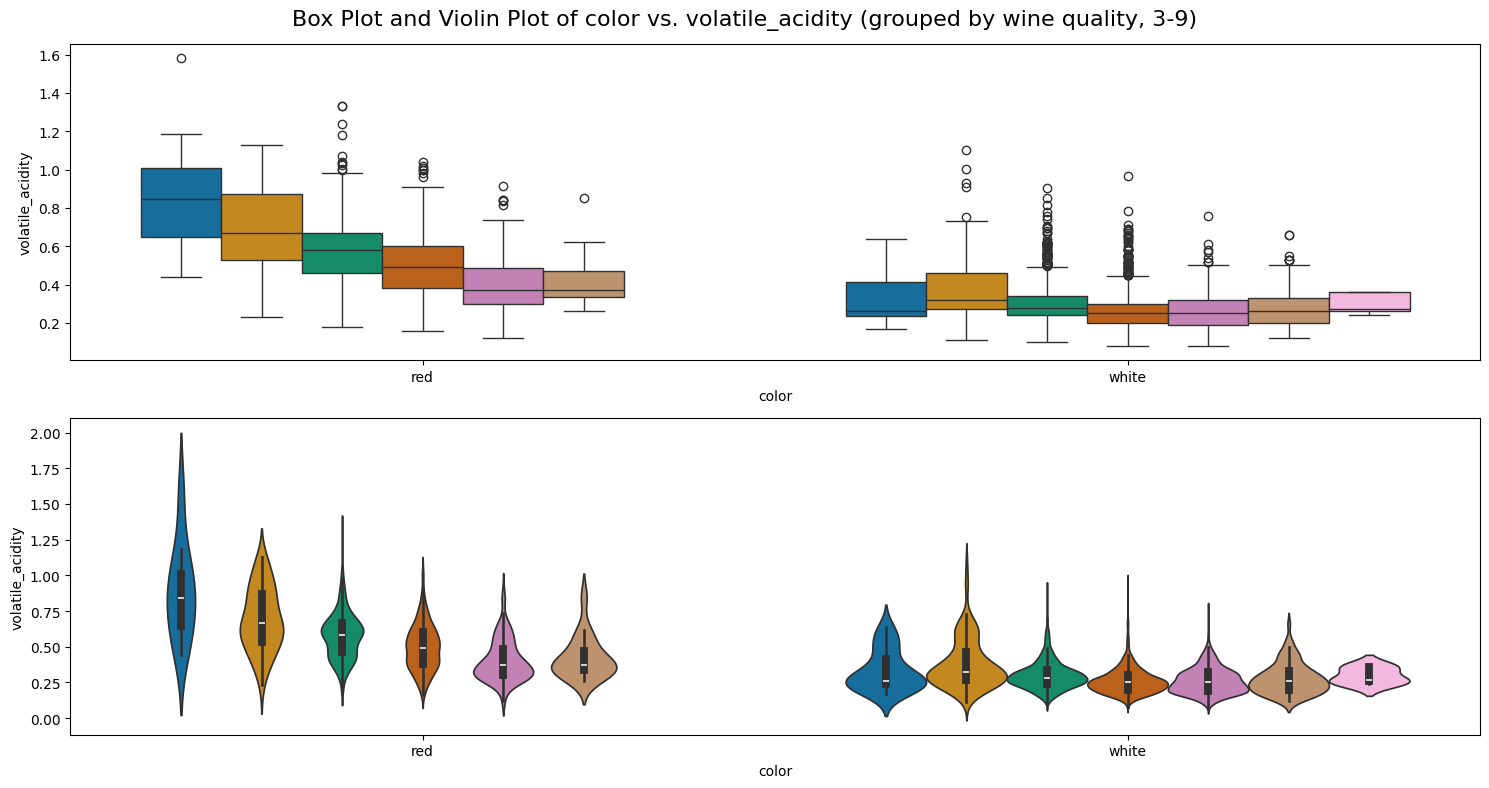

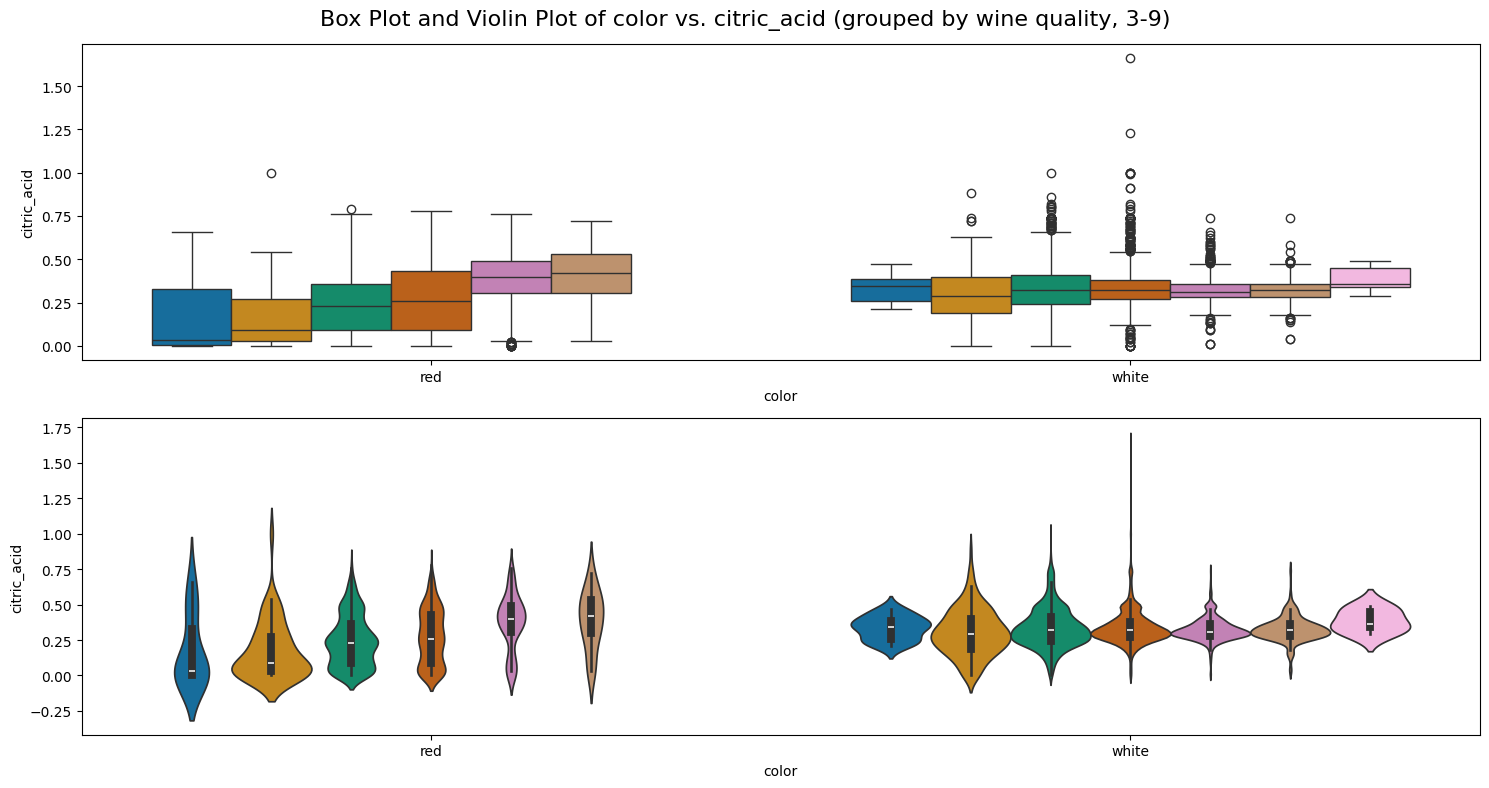

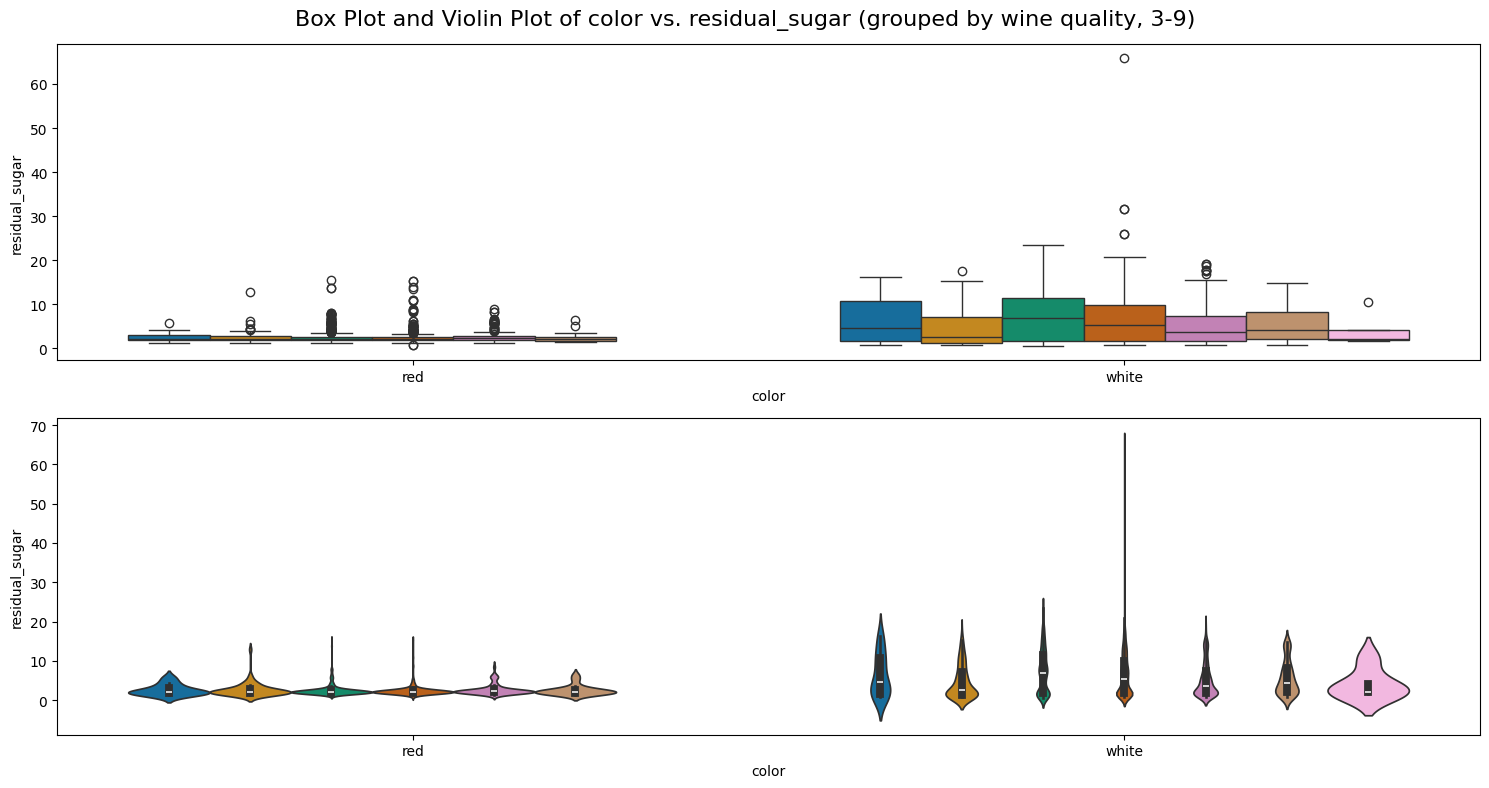

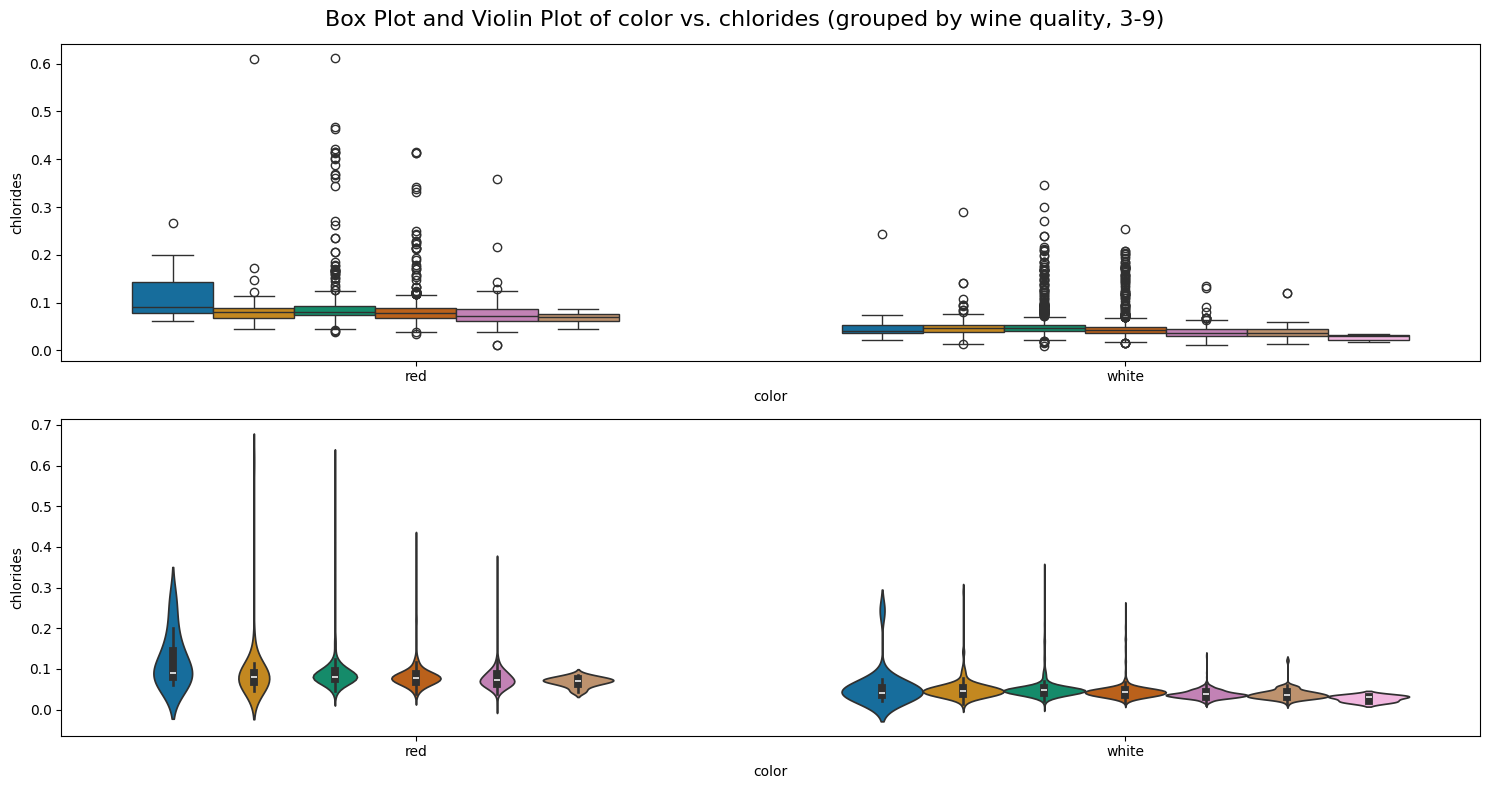

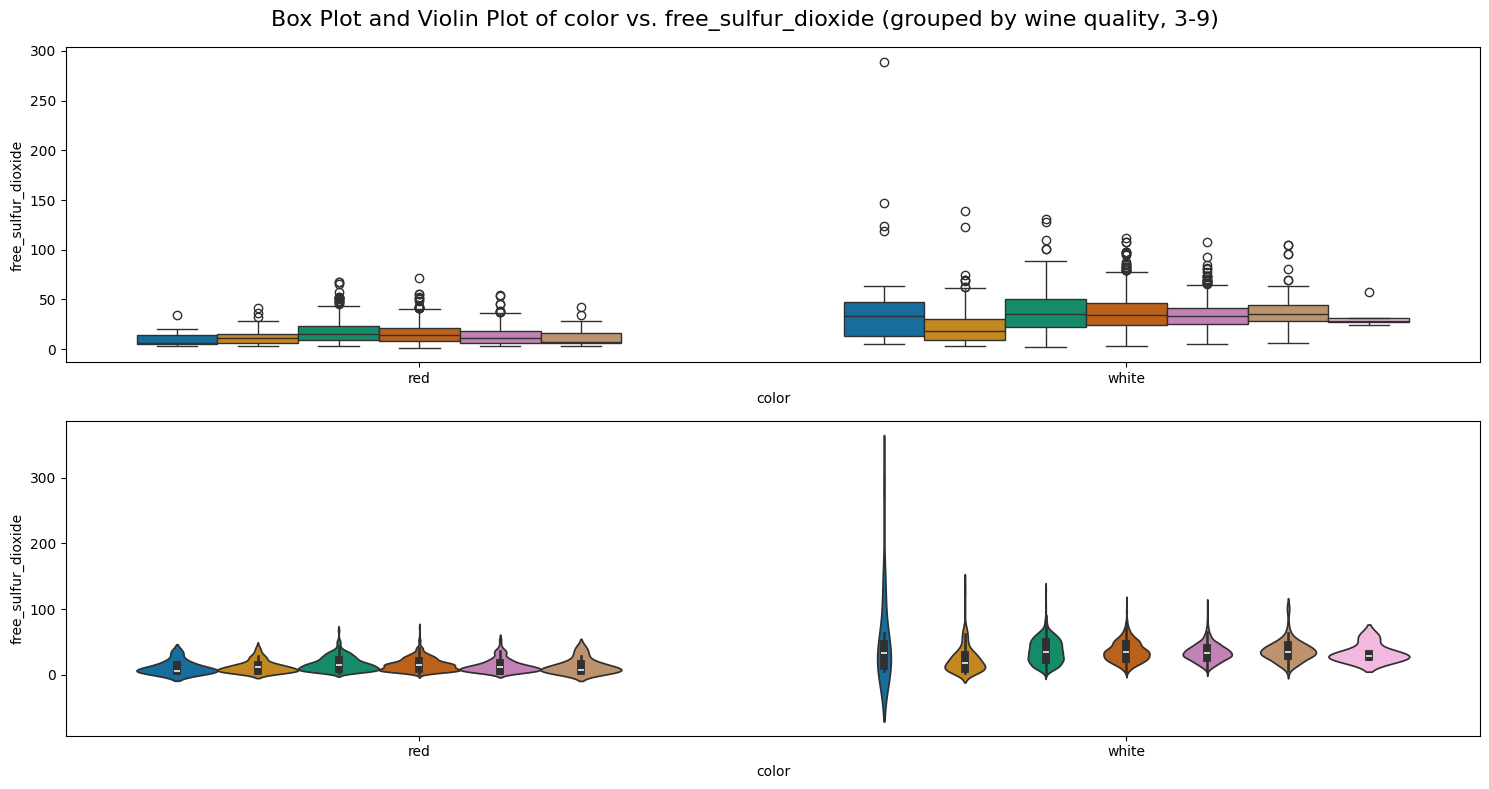

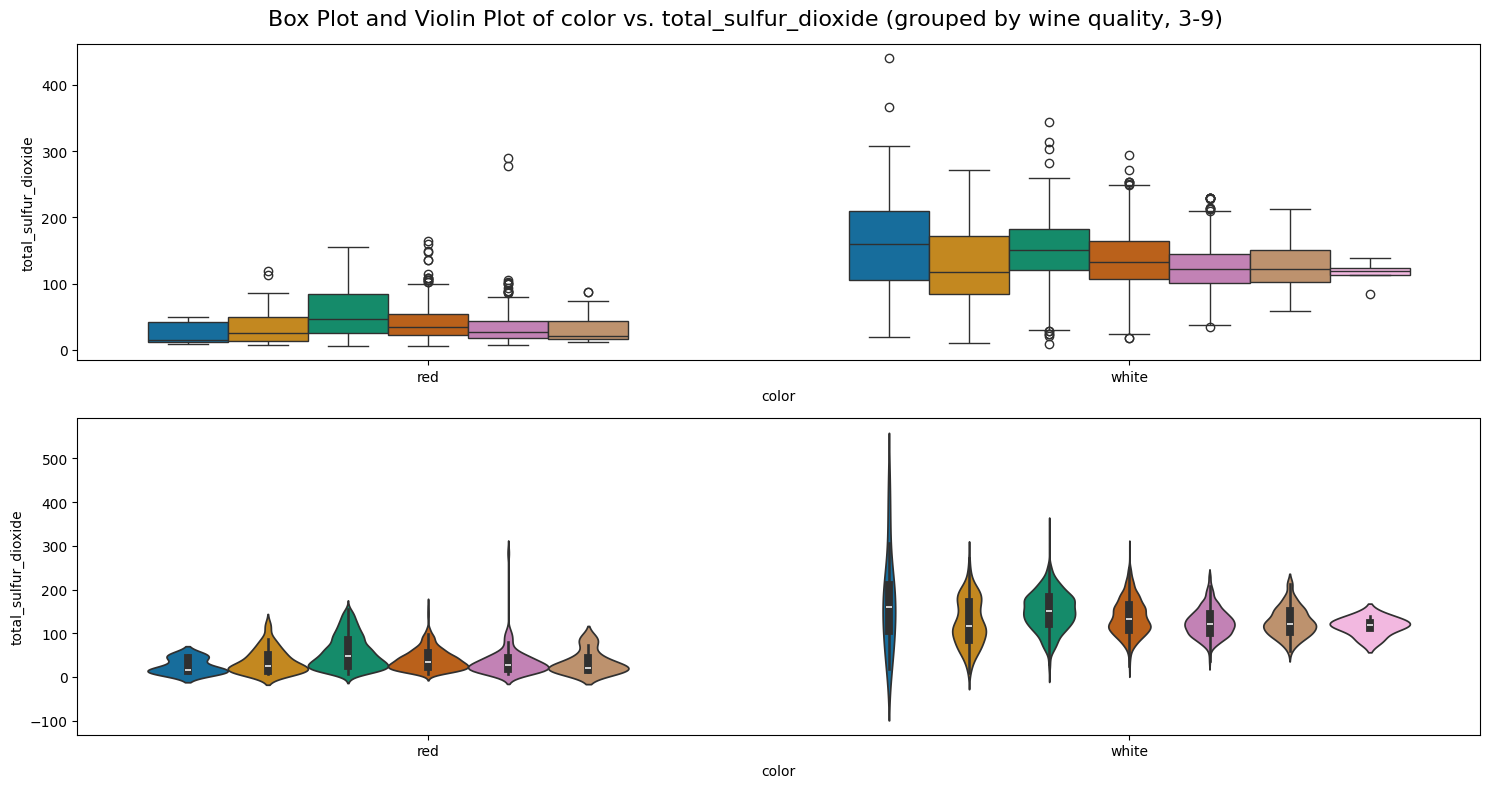

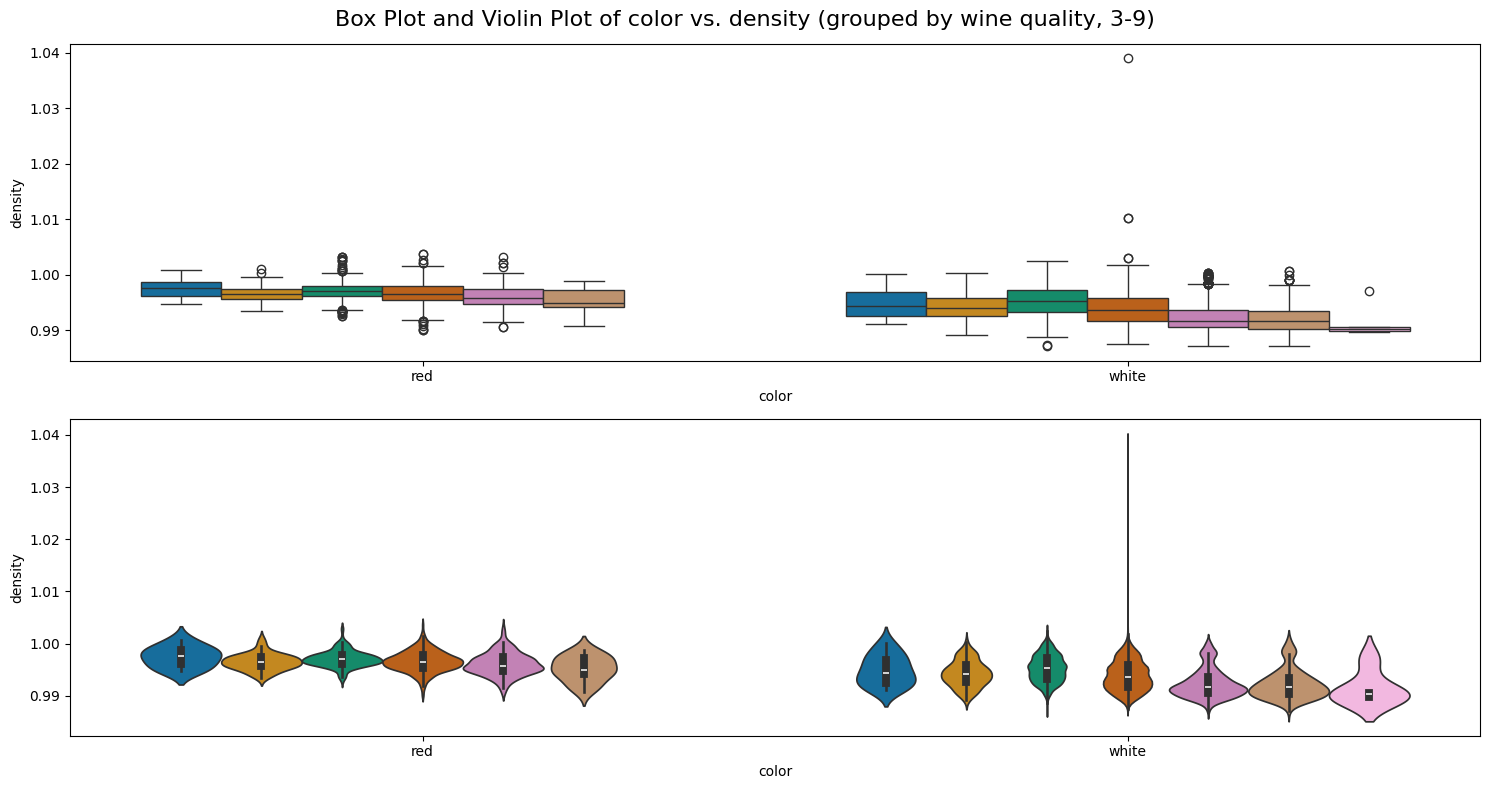

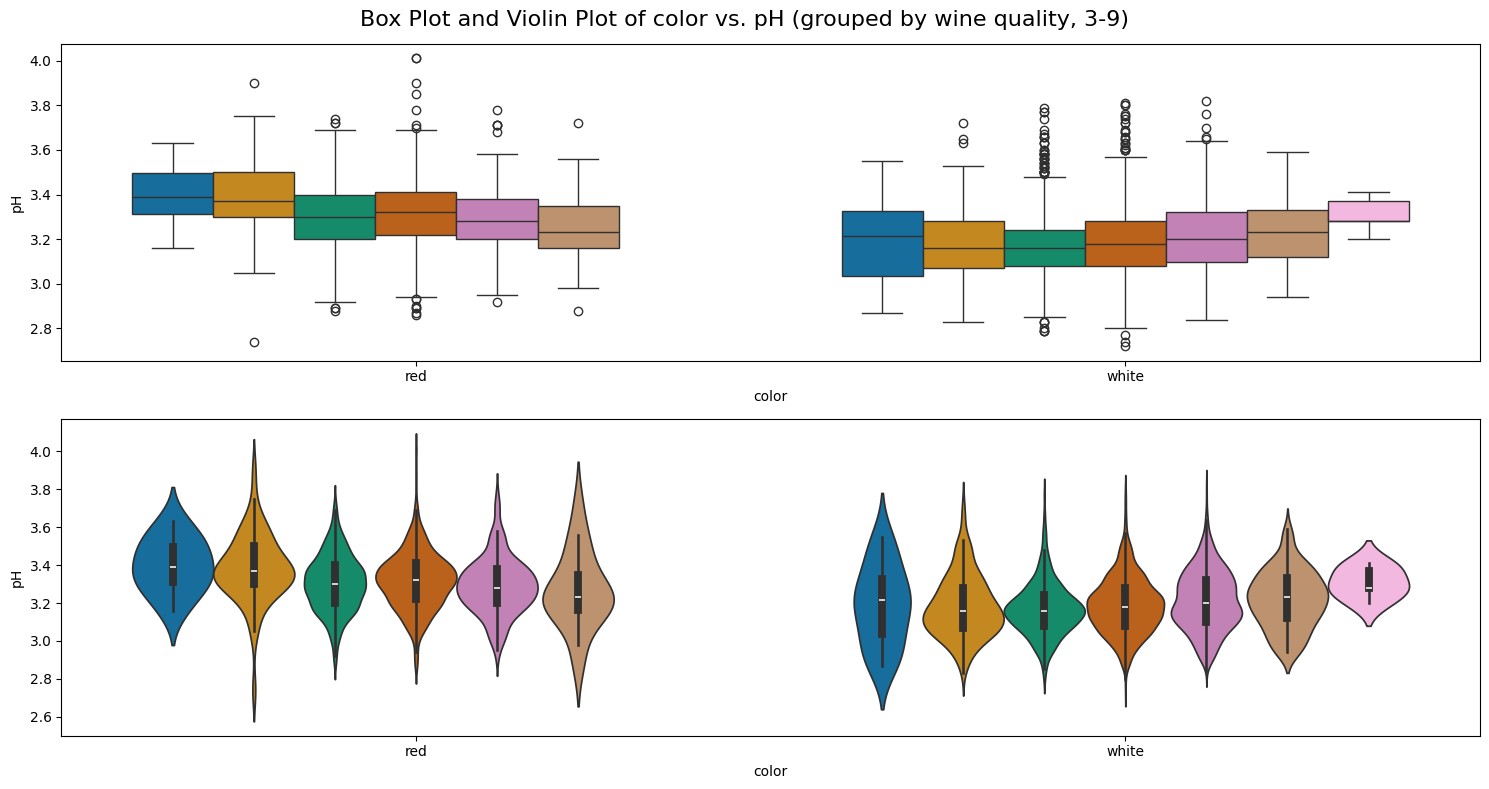

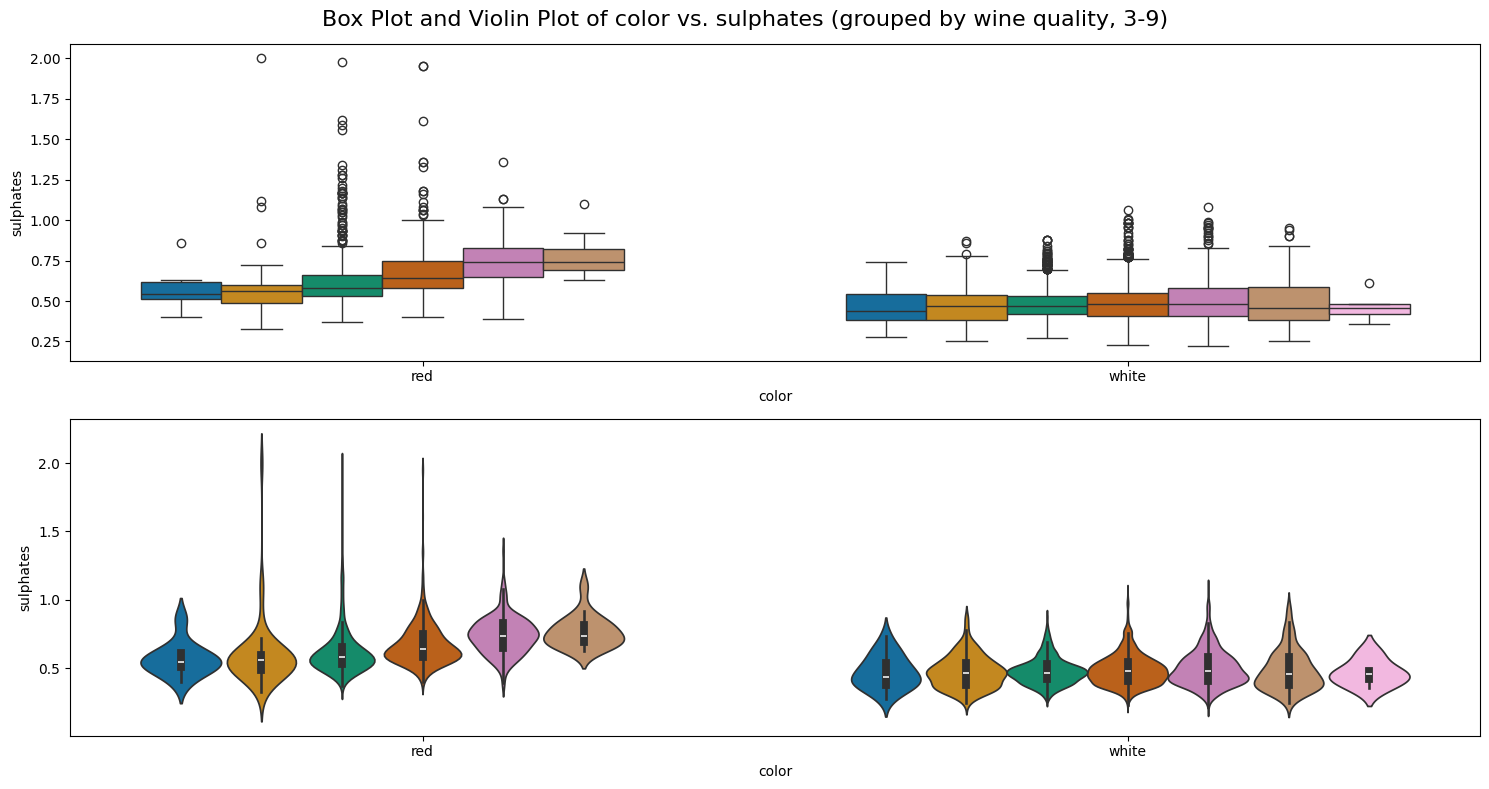

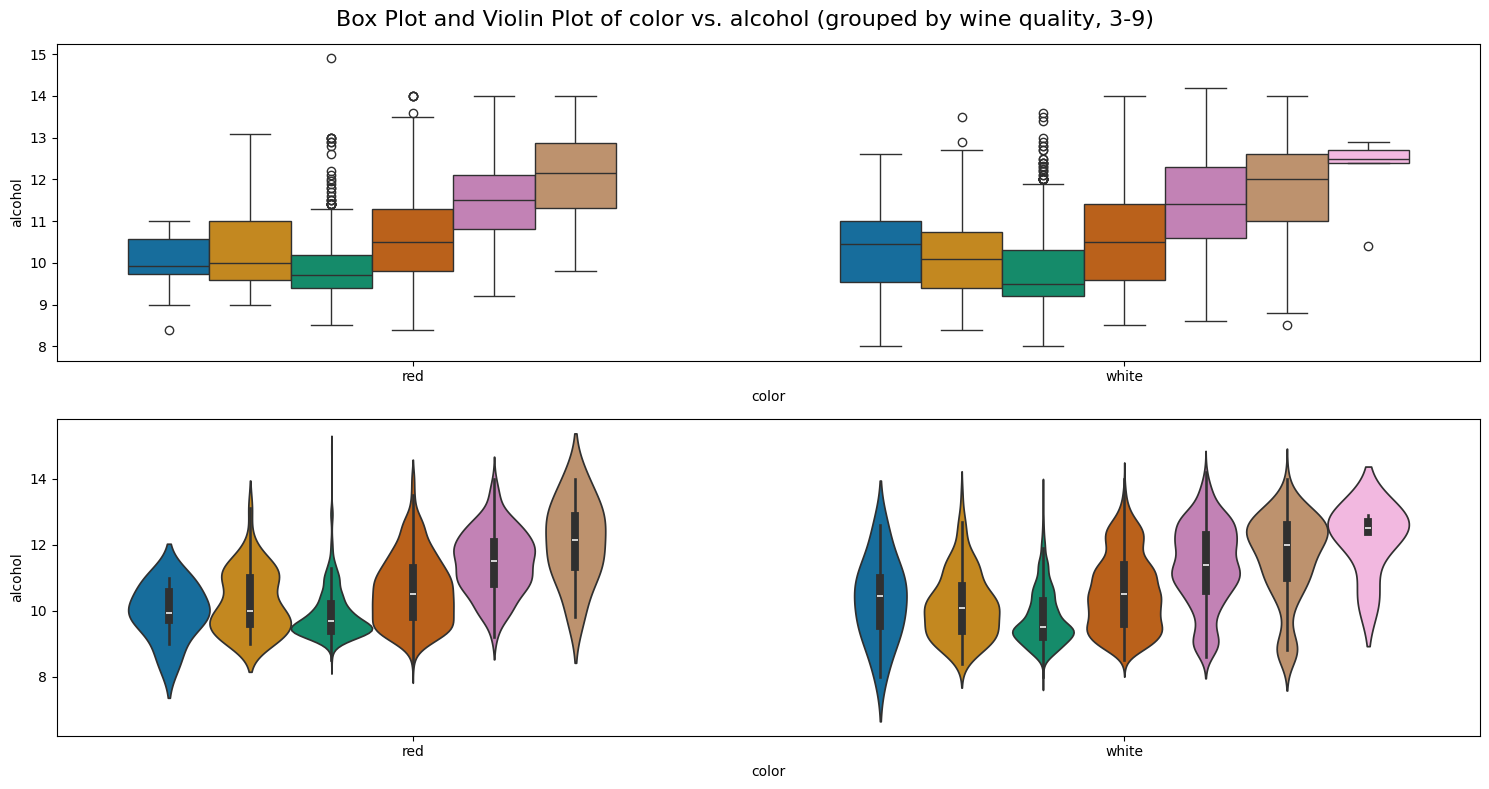

In [16]:
# visualizing distribution of features with respect to wine color, grouped by wine quality
for feature in feature_column_names:
    # setting up the subplots
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8))  # 2 rows, 1 column

    # creating the box plot
    sns.boxplot(data=wine_quality_df, x="color", y=f"{feature}", hue="quality", palette="colorblind", legend=False, ax=axes[0])
    axes[0].set_xlabel('color')
    axes[0].set_ylabel(f'{feature}')

    # creating the violin plot
    sns.violinplot(data=wine_quality_df, x="color", y=f"{feature}", hue="quality", palette="colorblind", legend=False, ax=axes[1])
    axes[1].set_xlabel('color')
    axes[1].set_ylabel(f'{feature}')

    fig.suptitle(f'Box Plot and Violin Plot of color vs. {feature} (grouped by wine quality, 3-9)', fontsize=16)
    plt.tight_layout()
    plt.show()

    print() # for spacing between plots

As can be seen from the box plots and violin plots, there are features wherein we can see a large variation with regards to the wine color. For instance, there is large variation in `citric_acid`, `residual_sugar`, `free_sulfur_dioxide`, and `total_sulfur_dioxide` between red and white wine.

Further EDA can be conducted depending on the objective of the model to be fitted. Here, it is assumed that the target is wine quality or color using the continuous variables as features.

Note also that feature transformation is not done here because it is to be done later as part of data preparation to ready the data for model fitting. 